# Week 4 — 1D CNN on Raw Folded Flux
Trains a lightweight 1D CNN directly on the 200-point phase-folded flux arrays. Uses the **same merge + split logic as Week 3** (same rows, same seed=42 stratified split) so the test set is identical across BLS_baseline / RF_main / RF_with_robovetter / CNN_1D — required for the comparison table to be valid.

**Design decisions (for the methods writeup):**
- 3 conv blocks (16→32→64 filters), kept shallow/narrow relative to the ~4,500-example dataset to avoid overparameterizing — AstroNet-style depth assumes a much larger training set with dual views
- Global Average Pooling instead of Flatten+Dense before the classifier head — cuts parameter count substantially vs. flattening, which matters directly for overfitting risk at this dataset size
- Three independent regularizers: Dropout, weight decay (AdamW), early stopping on validation loss
- All seeds fixed (torch/numpy/cuda) for reproducibility

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, re, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

DRIVE_ROOT = '/content/drive/MyDrive/SADA'
CSV_PATH   = os.path.join(DRIVE_ROOT, 'balanced_tce.csv')
NPY_DIR    = os.path.join(DRIVE_ROOT, 'processed')
CKPT_PATH  = os.path.join(DRIVE_ROOT, 'cnn_1d_best.pt')
RESULTS_PATH = os.path.join(DRIVE_ROOT, 'model_results.csv')

Mounted at /content/drive
Device: cuda


## 1. Rebuild the exact same row set + split as Week 3
Same merge, same `dropna` on BLS columns (even though the CNN won't use them — this keeps the row set identical to Week 3 so indices line up), same stratified 70/15/15 split, seed 42.

In [ ]:
balanced = pd.read_csv(CSV_PATH)

npy_files = [f for f in os.listdir(NPY_DIR) if f.endswith('.npy') and f != 'failed_kepids.npy']
pattern = re.compile(r'^(\d+)_(\d+)_(PC|FP)\.npy$')
records = []
for fname in npy_files:
    m = pattern.match(fname)
    if not m:
        continue
    kepid, plnt_num, label_str = m.groups()
    records.append({
        'kepid': int(kepid), 'tce_plnt_num': int(plnt_num),
        'label': 1 if label_str == 'PC' else 0,
        'npy_path': os.path.join(NPY_DIR, fname)
    })
npy_index = pd.DataFrame(records)

data = pd.merge(npy_index, balanced, on=['kepid', 'tce_plnt_num'], how='inner')
data = data.dropna(subset=['tce_period','tce_duration','tce_depth','tce_model_snr']).reset_index(drop=True)
print(f"Row set: {len(data)} (should match Week 3's post-dropna count)")

Row set: 4515 (should match Week 3's post-dropna count)


In [ ]:
print(balanced['disposition'].value_counts())
print(f"Total rows: {len(balanced)}")

disposition
PC    4037
FP    4037
Name: count, dtype: int64
Total rows: 8074


In [ ]:
from sklearn.model_selection import train_test_split

y = data['label'].values

idx_train, idx_temp = train_test_split(
    data.index, test_size=0.30, random_state=42, stratify=y)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, random_state=42, stratify=y[idx_temp])

train_df, val_df, test_df = data.loc[idx_train], data.loc[idx_val], data.loc[idx_test]
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 3160 | Val: 677 | Test: 678


## 2. Dataset + DataLoaders
Same `KeplerDataset` pattern as your Week 2 cell 19, adapted to read from the split DataFrames and reshape to `(1, 200)` — Conv1d expects `(channels, length)`.

In [ ]:
class KeplerFluxDataset(Dataset):
    def __init__(self, df):
        # preload all arrays into memory ONCE — avoids per-epoch Drive I/O
        self.fluxes = np.stack([np.load(p).astype(np.float32) for p in df['npy_path'].values])
        self.labels = df['label'].values.astype(np.float32)

    def __len__(self):
        return len(self.fluxes)

    def __getitem__(self, idx):
        flux = torch.tensor(self.fluxes[idx]).unsqueeze(0)
        label = torch.tensor(self.labels[idx])
        return flux, label

BATCH_SIZE = 64
train_ds = KeplerFluxDataset(train_df)
val_ds   = KeplerFluxDataset(val_df)
test_ds  = KeplerFluxDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches -> train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Batches -> train: 50, val: 11, test: 11


## 3. Model — shallow 1D CNN with Global Average Pooling

In [ ]:
class Conv1DClassifier(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=5, padding=2),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(8, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).squeeze(-1)
        return self.head(x).squeeze(-1)

model = Conv1DClassifier().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(f"Params-to-training-examples ratio: {n_params / len(train_df):.2f}")

Trainable parameters: 3,953
Params-to-training-examples ratio: 1.25


## 4. Training loop — early stopping on val loss
`BCEWithLogitsLoss` (numerically stable, works directly on the raw logits from the model — no sigmoid needed in the forward pass). AdamW gives weight decay as a built-in regularizer separate from Dropout.

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

N_EPOCHS = 60
PATIENCE = 8

best_val_loss = float('inf')
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses, correct, total = [], 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_losses.append(loss.item())
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    val_acc = correct / total
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (no val_loss improvement for {PATIENCE} epochs)")
            break

print(f"\nBest val_loss: {best_val_loss:.4f} — checkpoint saved to {CKPT_PATH}")

Epoch 01 | train_loss=0.6798 | val_loss=0.6616 | val_acc=0.6307
Epoch 02 | train_loss=0.6455 | val_loss=0.6169 | val_acc=0.6677
Epoch 03 | train_loss=0.6147 | val_loss=0.5743 | val_acc=0.7341
Epoch 04 | train_loss=0.5897 | val_loss=0.5445 | val_acc=0.7445
Epoch 05 | train_loss=0.5728 | val_loss=0.5208 | val_acc=0.7637
Epoch 06 | train_loss=0.5637 | val_loss=0.5122 | val_acc=0.7637
Epoch 07 | train_loss=0.5523 | val_loss=0.5037 | val_acc=0.7725
Epoch 08 | train_loss=0.5514 | val_loss=0.5059 | val_acc=0.7607
Epoch 09 | train_loss=0.5507 | val_loss=0.5130 | val_acc=0.7371
Epoch 10 | train_loss=0.5320 | val_loss=0.4926 | val_acc=0.7607
Epoch 11 | train_loss=0.5374 | val_loss=0.5274 | val_acc=0.7238
Epoch 12 | train_loss=0.5307 | val_loss=0.5209 | val_acc=0.7386
Epoch 13 | train_loss=0.5398 | val_loss=0.4946 | val_acc=0.7696
Epoch 14 | train_loss=0.5238 | val_loss=0.4856 | val_acc=0.7784
Epoch 15 | train_loss=0.5206 | val_loss=0.4751 | val_acc=0.7799
Epoch 16 | train_loss=0.5241 | val_loss=

## 5. Training curves (for the paper's figures)

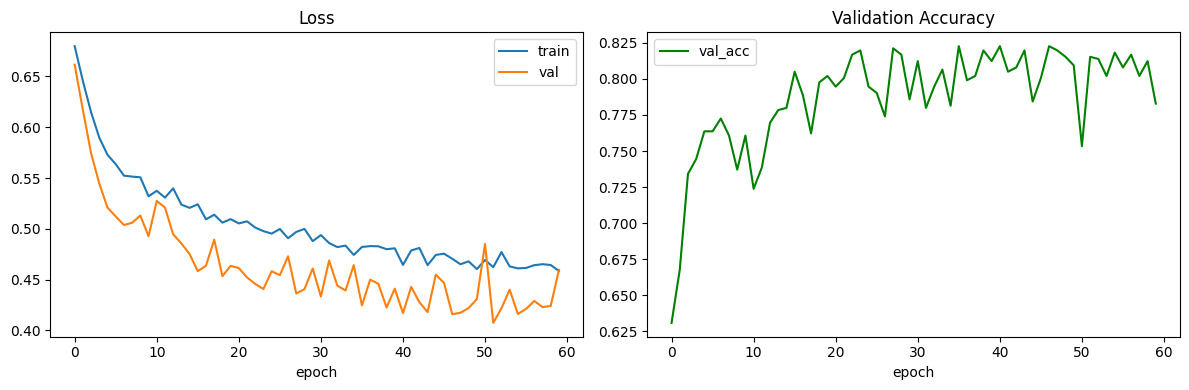

Saved figure to /content/drive/MyDrive/SADA/cnn_training_curves.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(history['val_acc'], label='val_acc', color='green')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(DRIVE_ROOT, 'cnn_training_curves.png')
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved figure to {fig_path}")

## 6. Load best checkpoint, evaluate on test set — same metrics as Week 3

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(yb.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs > 0.5).astype(int)

cnn_result = {
    'model': 'CNN_1D',
    'n_features': 200,
    'accuracy': accuracy_score(all_labels, all_preds),
    'precision': precision_score(all_labels, all_preds),
    'recall': recall_score(all_labels, all_preds),
    'f1': f1_score(all_labels, all_preds),
    'roc_auc': roc_auc_score(all_labels, all_probs),
}

print('=== CNN_1D (test set) ===')
for k, v in cnn_result.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print('  confusion matrix:\n', confusion_matrix(all_labels, all_preds))

=== CNN_1D (test set) ===
  model: CNN_1D
  n_features: 200
  accuracy: 0.8097
  precision: 0.7962
  recall: 0.8486
  f1: 0.8216
  roc_auc: 0.8868
  confusion matrix:
 [[252  76]
 [ 53 297]]


## 7. Append to the running results log alongside Week 3's models

In [ ]:
results_df = pd.DataFrame([cnn_result])

if os.path.exists(RESULTS_PATH):
    prior = pd.read_csv(RESULTS_PATH)
    combined = pd.concat([prior, results_df], ignore_index=True)
else:
    combined = results_df

combined.to_csv(RESULTS_PATH, index=False)
print(f"Saved to {RESULTS_PATH}")
combined